<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/unsupervised/clustering/experiment_kmeans_customer_segmentation_elbow_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

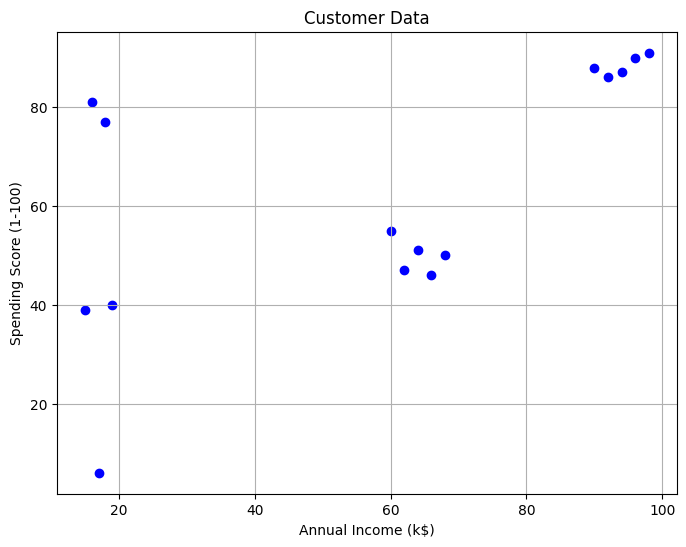

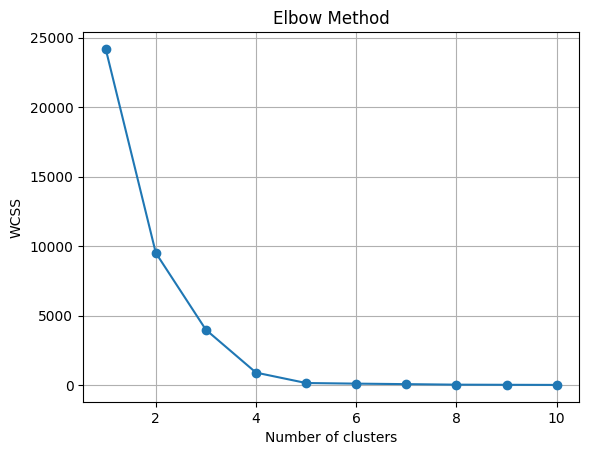

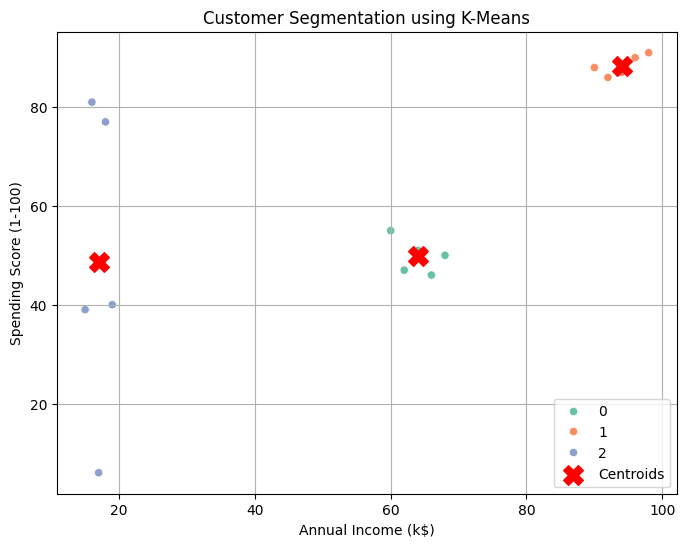

In [ ]:
# K-MEANS PROJECT

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


# Sample dataset: Annual Income and Spending Score
data = {
    'Annual Income (k$)': [15, 16, 17, 18, 19, 60, 62, 64, 66, 68, 90, 92, 94, 96, 98],
    'Spending Score (1-100)': [39, 81, 6, 77, 40, 55, 47, 51, 46, 50, 88, 86, 87, 90, 91]
}
df = pd.DataFrame(data)
df.head()


# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='blue')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data')
plt.grid(True)
plt.show()


# Apply K-Means clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Find optimal number of clusters using Elbow Method
abc = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    abc.append(kmeans.inertia_)

# Plot elbow graph
plt.plot(range(1, 11), abc, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


# From the elbow plot, let's choose 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set2')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.grid(True)
plt.show()